# Assignment 4

Before working on this assignment please read these instructions fully. In the submission area, you will notice that you can click the link to **Preview the Grading** for each step of the assignment. This is the criteria that will be used for peer grading. Please familiarize yourself with the criteria before beginning the assignment.

This assignment requires that you find **at least two datasets** on the web which are related, and that you visualize these datasets to answer the assignment question. You are free to utilize datasets with any location or domain, the usage of **Ann Arbor sports and athletics** datasets in the example is just a suggestion.

You are welcome to choose datasets at your discretion, but keep in mind **they will be shared with your peers**, so choose appropriate datasets. Sensitive, confidential, illicit, and proprietary materials are not good choices for datasets for this assignment. You are welcome to upload datasets of your own as well, and link to them using a third party repository such as github, pastebin, etc. Please be aware of the Coursera terms of service with respect to intellectual property.

Also, you are welcome to preserve data in its original language, but for the purposes of grading you should provide english translations. You are welcome to provide multiple visuals in different languages if you would like!

As this assignment is for the whole course, you must incorporate principles discussed in the first week, such as having as high data-ink ratio (Tufte) and aligning with Cairo’s principles of truth, beauty, function, and insight.

Here are the assignment instructions:

 * You must state a question you are seeking to answer with your visualizations.
 * You must provide at least two links to available datasets. These could be links to files such as CSV or Excel files, or links to websites which might have data in tabular form, such as Wikipedia pages.
 * You must upload an image which addresses the research question you stated. In addition to addressing the question, this visual should follow Cairo's principles of truthfulness, functionality, beauty, and insightfulness.
 * You must contribute a short (1-2 paragraph) written justification of how your visualization addresses your stated research question.

## Tips
* Wikipedia is an excellent source of data, and I strongly encourage you to explore it for new data sources.
* Many governments run open data initiatives at the city, region, and country levels, and these are wonderful resources for localized data sources.
* Several international agencies, such as the [United Nations](http://data.un.org/), the [World Bank](http://data.worldbank.org/), the [Global Open Data Index](http://index.okfn.org/place/) are other great places to look for data.
* This assignment requires you to convert and clean datafiles. Check out the discussion forums for tips on how to do this from various sources, and share your successes with your fellow students!

## Example
Looking for an example? Here's what our course assistant put together as an example! [Example Solution File](./Example/Assignment4_example.pdf)

# Climate Change: CO2 and Temperature Anomaly Analysis

## 1. Region and Domain
* **Region**: Global (Atmospheric measurements from Mauna Loa Observatory, Hawaii, and global land-ocean surface temperatures)
* **Domain**: Environmental Science / Climatology

## 2. Research Question
*How has the monthly atmospheric carbon dioxide concentration (CO2 in ppm) measured at Mauna Loa correlated with global land-ocean temperature anomalies (relative to the 1951-1980 baseline) from 1959 to the present, and how does this relationship visualize the rate of global warming?*

## 3. Dataset Links
* **Atmospheric Carbon Dioxide (CO2) concentrations**:
  - Source: NOAA Global Monitoring Laboratory (GML)
  - URL: [https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv](https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv)
  - Details: Monthly mean CO2 concentration (in ppm) measured at Mauna Loa Observatory, Hawaii.
* **Global Land-Ocean Temperature Index (GISTEMP)**:
  - Source: NASA Goddard Institute for Space Studies (GISS)
  - URL: [https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv](https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv)
  - Details: Monthly global surface temperature anomalies relative to the 1951-1980 base period.

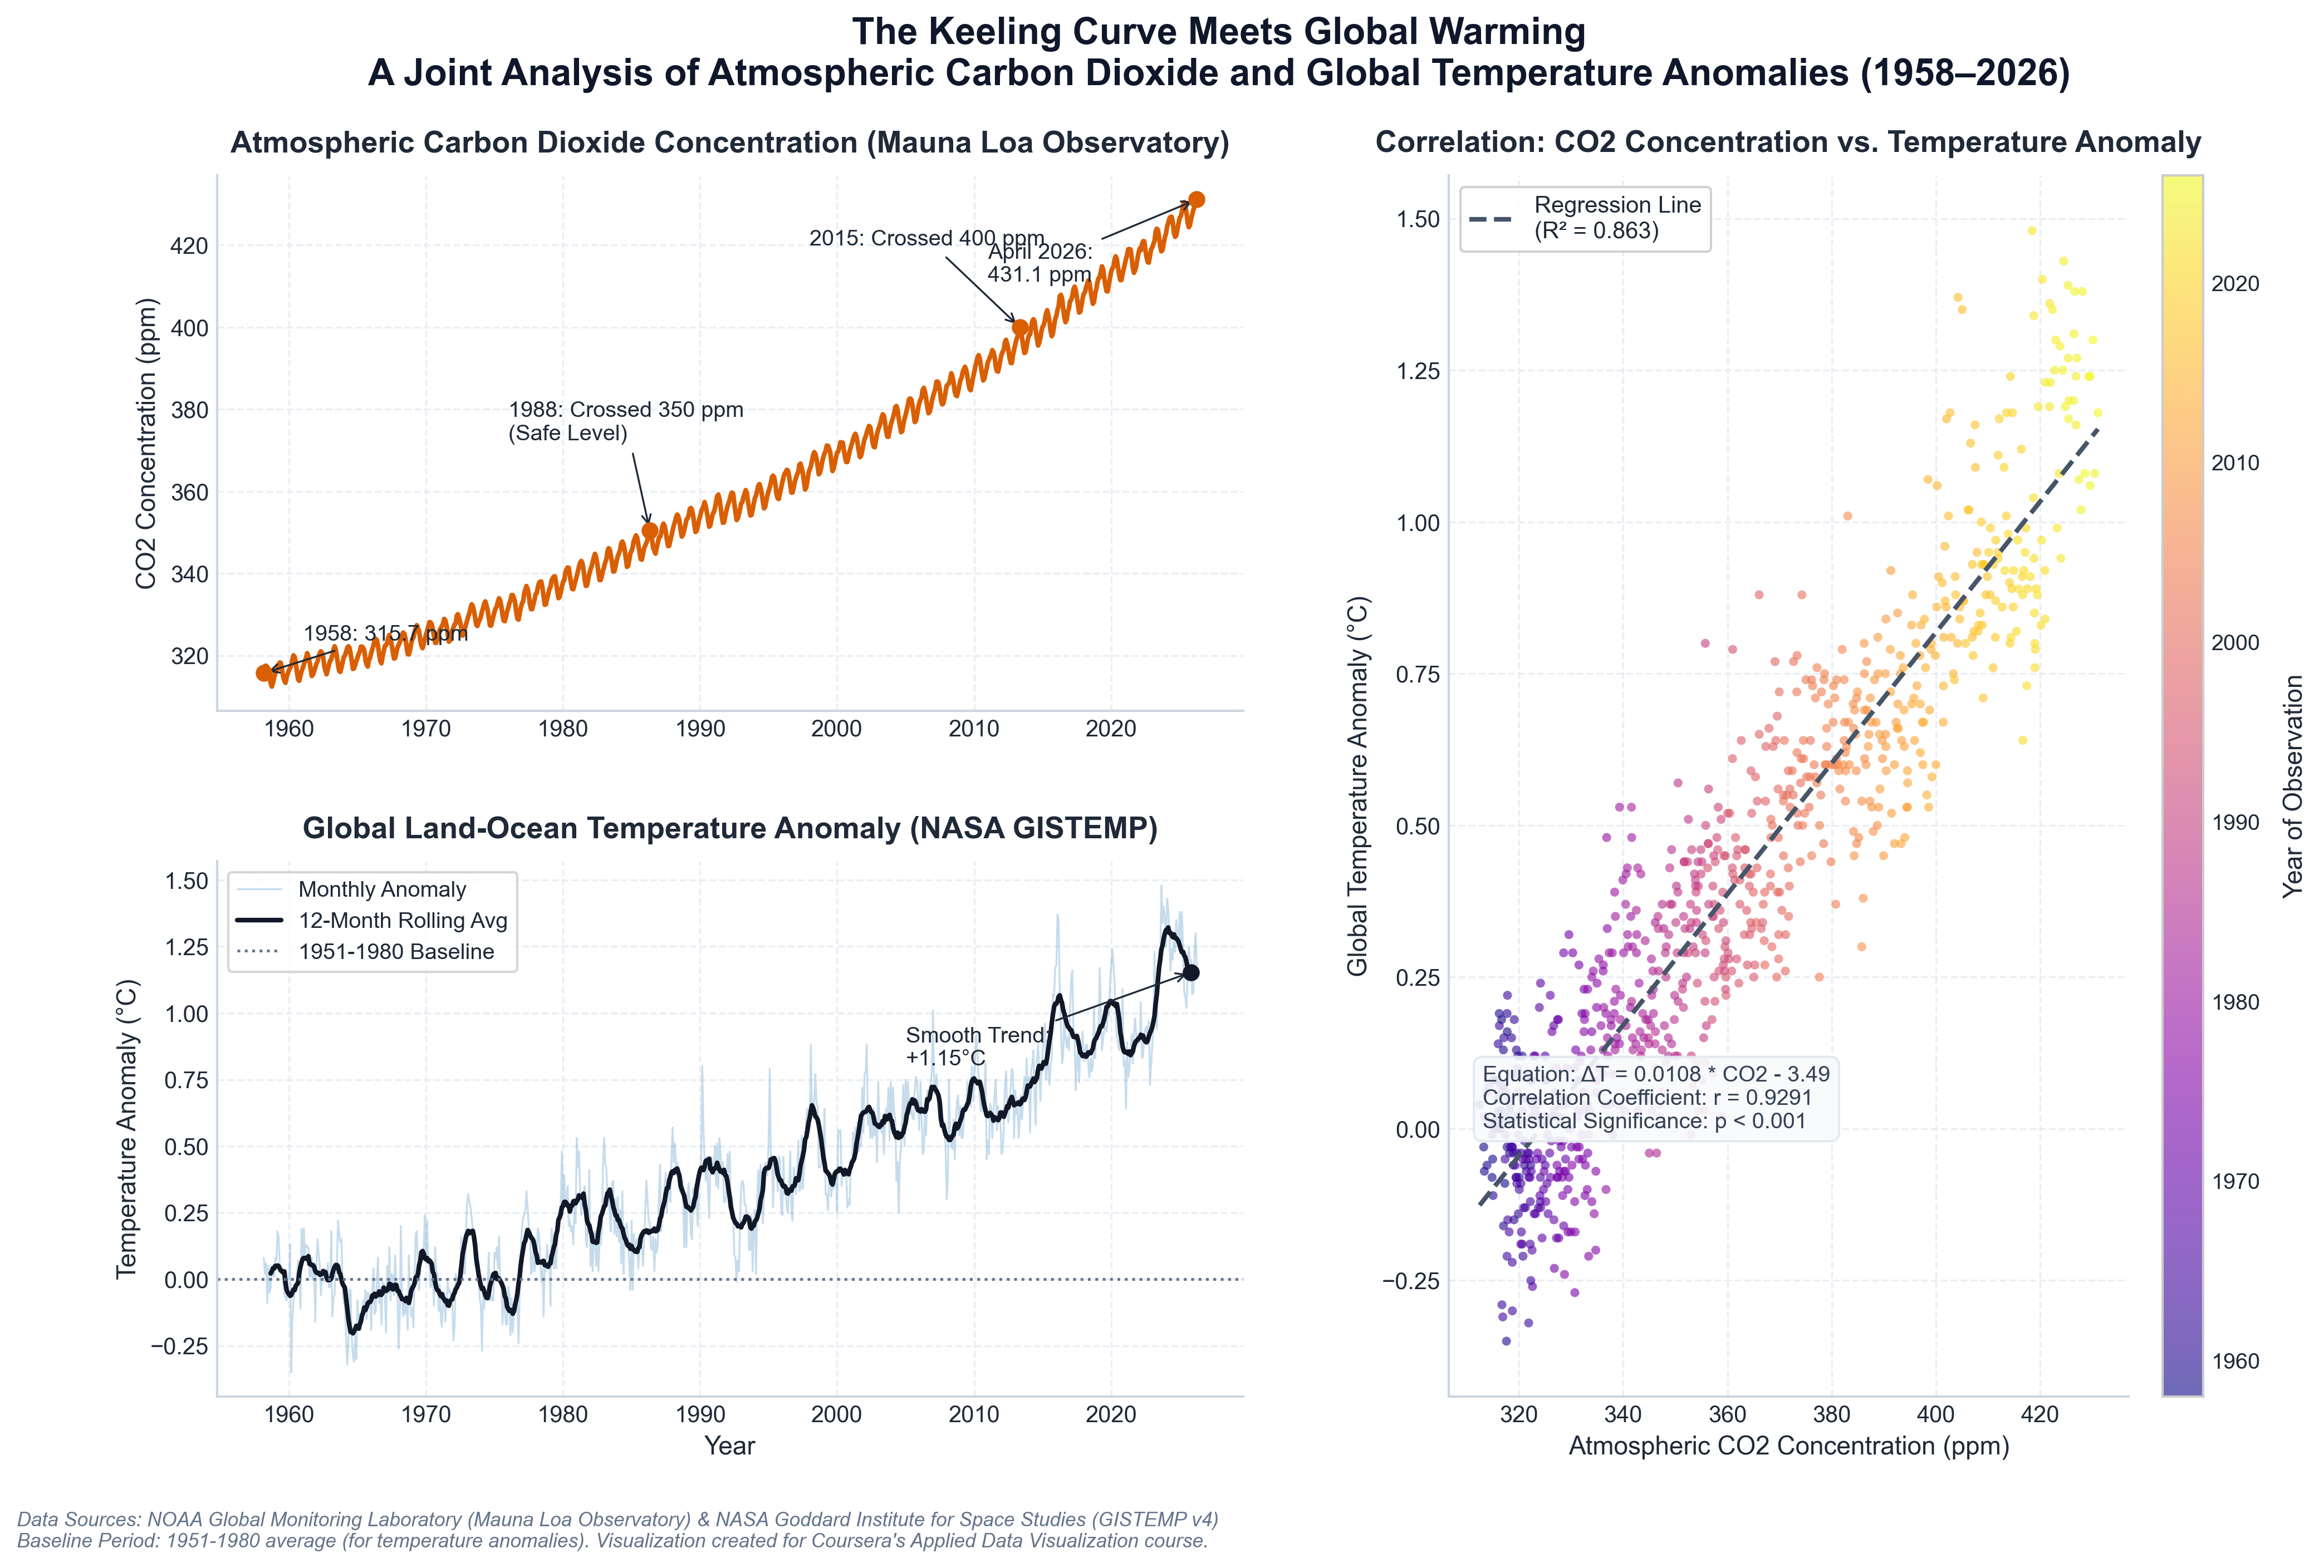

In [ ]:
# Loading raw datasets:
# - NOAA Mauna Loa Carbon Dioxide levels
# - NASA GISTEMP global temperature anomalies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import linregress
%matplotlib inline

# 1. Load and Clean Data
co2_url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv"
temp_url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"

# CO2
df_co2 = pd.read_csv(co2_url, comment='#')
df_co2 = df_co2[df_co2['average'] > 0]
df_co2 = df_co2[['year', 'month', 'average']].rename(columns={'year': 'Year', 'month': 'Month', 'average': 'CO2_ppm'})

# Temperature
df_temp = pd.read_csv(temp_url, skiprows=1)
df_temp['Year'] = pd.to_numeric(df_temp['Year'], errors='coerce')
df_temp = df_temp.dropna(subset=['Year'])
df_temp['Year'] = df_temp['Year'].astype(int)

month_cols = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_temp = df_temp[['Year'] + month_cols]
df_temp_melted = df_temp.melt(id_vars=['Year'], value_vars=month_cols, var_name='Month_Name', value_name='Temp_Anomaly')
month_map = {name: idx+1 for idx, name in enumerate(month_cols)}
df_temp_melted['Month'] = df_temp_melted['Month_Name'].map(month_map)
df_temp_melted['Temp_Anomaly'] = pd.to_numeric(df_temp_melted['Temp_Anomaly'], errors='coerce')
df_temp_melted = df_temp_melted.dropna()

# Merge
df = pd.merge(df_co2, df_temp_melted, on=['Year', 'Month'], how='inner')
df = df.sort_values(['Year', 'Month']).reset_index(drop=True)
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))

# Calculate 12-month rolling average for temperature anomaly
df['Temp_Anomaly_Smooth'] = df['Temp_Anomaly'].rolling(window=12, center=True).mean()

# 2. Setup Figure and GridSpec
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig = plt.figure(figsize=(16, 9.5), dpi=300)
gs = gridspec.GridSpec(2, 2, width_ratios=[1.1, 0.9], wspace=0.22, hspace=0.28)

# Color constants
co2_color = '#d95f02'       # Warm copper/orange-red for CO2
temp_color = '#1f77b4'      # Ocean blue for temp anomaly raw
smooth_temp_color = '#111827' # Very dark charcoal for smoothed trend
grid_color = '#e2e8f0'      # Soft slate for gridlines
text_color = '#1f2937'      # Dark gray for text

# Set font parameters
plt.rcParams['text.color'] = text_color
plt.rcParams['axes.labelcolor'] = text_color
plt.rcParams['xtick.color'] = text_color
plt.rcParams['ytick.color'] = text_color
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'

# Define subplots
ax_co2 = fig.add_subplot(gs[0, 0])
ax_temp = fig.add_subplot(gs[1, 0], sharex=ax_co2)
ax_scatter = fig.add_subplot(gs[:, 1])

# --- Subplot 1: CO2 Time Series ---
ax_co2.plot(df['Date'], df['CO2_ppm'], color=co2_color, linewidth=2, label='CO2 (ppm)')
ax_co2.set_title("Atmospheric Carbon Dioxide Concentration (Mauna Loa Observatory)", fontsize=13, fontweight='semibold', pad=10)
ax_co2.set_ylabel("CO2 Concentration (ppm)", fontsize=11, fontweight='medium')
ax_co2.grid(True, linestyle='--', color=grid_color, alpha=0.7)
ax_co2.spines['top'].set_visible(False)
ax_co2.spines['right'].set_visible(False)
ax_co2.spines['left'].set_color('#cbd5e1')
ax_co2.spines['bottom'].set_color('#cbd5e1')

# Add milestones to CO2 plot
# 1958 start
start_row = df.iloc[0]
ax_co2.scatter(start_row['Date'], start_row['CO2_ppm'], color=co2_color, s=40, zorder=5)
ax_co2.annotate(f"1958: {start_row['CO2_ppm']:.1f} ppm", 
                xy=(start_row['Date'], start_row['CO2_ppm']), 
                xytext=(pd.to_datetime('1961-01-01'), start_row['CO2_ppm'] + 8),
                arrowprops=dict(arrowstyle="->", color=text_color, lw=0.8),
                fontsize=9.5, fontweight='medium')

# 350 ppm milestone (1988)
row_350 = df[df['CO2_ppm'] >= 350.0].iloc[0]
ax_co2.scatter(row_350['Date'], row_350['CO2_ppm'], color=co2_color, s=40, zorder=5)
ax_co2.annotate(f"1988: Crossed 350 ppm\n(Safe Level)", 
                xy=(row_350['Date'], row_350['CO2_ppm']), 
                xytext=(pd.to_datetime('1976-01-01'), row_350['CO2_ppm'] + 22),
                arrowprops=dict(arrowstyle="->", color=text_color, lw=0.8),
                fontsize=9.5, fontweight='medium')

# 400 ppm milestone (2015)
row_400 = df[df['CO2_ppm'] >= 400.0].iloc[0]
ax_co2.scatter(row_400['Date'], row_400['CO2_ppm'], color=co2_color, s=40, zorder=5)
ax_co2.annotate(f"2015: Crossed 400 ppm", 
                xy=(row_400['Date'], row_400['CO2_ppm']), 
                xytext=(pd.to_datetime('1998-01-01'), row_400['CO2_ppm'] + 20),
                arrowprops=dict(arrowstyle="->", color=text_color, lw=0.8),
                fontsize=9.5, fontweight='medium')

# Recent value
end_row = df.iloc[-1]
ax_co2.scatter(end_row['Date'], end_row['CO2_ppm'], color=co2_color, s=40, zorder=5)
ax_co2.annotate(f"April 2026:\n{end_row['CO2_ppm']:.1f} ppm", 
                xy=(end_row['Date'], end_row['CO2_ppm']), 
                xytext=(pd.to_datetime('2011-01-01'), end_row['CO2_ppm'] - 20),
                arrowprops=dict(arrowstyle="->", color=text_color, lw=0.8),
                fontsize=9.5, fontweight='medium')


# --- Subplot 2: Temperature Anomaly Time Series ---
ax_temp.plot(df['Date'], df['Temp_Anomaly'], color=temp_color, alpha=0.25, linewidth=0.8, label='Monthly Anomaly')
ax_temp.plot(df['Date'], df['Temp_Anomaly_Smooth'], color=smooth_temp_color, linewidth=2, label='12-Month Rolling Avg')
ax_temp.axhline(0, color='#64748b', linestyle=':', linewidth=1.2, label='1951-1980 Baseline')
ax_temp.set_title("Global Land-Ocean Temperature Anomaly (NASA GISTEMP)", fontsize=13, fontweight='semibold', pad=10)
ax_temp.set_ylabel("Temperature Anomaly (°C)", fontsize=11, fontweight='medium')
ax_temp.set_xlabel("Year", fontsize=11, fontweight='medium')
ax_temp.grid(True, linestyle='--', color=grid_color, alpha=0.7)
ax_temp.spines['top'].set_visible(False)
ax_temp.spines['right'].set_visible(False)
ax_temp.spines['left'].set_color('#cbd5e1')
ax_temp.spines['bottom'].set_color('#cbd5e1')
ax_temp.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.8, fontsize=9.5)

# Annotate recent temperature anomaly
recent_smooth_temp = df['Temp_Anomaly_Smooth'].dropna().iloc[-1]
recent_smooth_date = df[df['Temp_Anomaly_Smooth'].notnull()].iloc[-1]['Date']
ax_temp.scatter(recent_smooth_date, recent_smooth_temp, color=smooth_temp_color, s=40, zorder=5)
ax_temp.annotate(f"Smooth Trend:\n+{recent_smooth_temp:.2f}°C", 
                 xy=(recent_smooth_date, recent_smooth_temp), 
                 xytext=(pd.to_datetime('2005-01-01'), recent_smooth_temp - 0.35),
                 arrowprops=dict(arrowstyle="->", color=text_color, lw=0.8),
                 fontsize=9.5, fontweight='medium')


# --- Subplot 3: Scatter Plot & Linear Regression ---
sc = ax_scatter.scatter(df['CO2_ppm'], df['Temp_Anomaly'], c=df['Year'], cmap='plasma', alpha=0.6, s=15, edgecolors='none')
cbar = fig.colorbar(sc, ax=ax_scatter, pad=0.04, aspect=30)
cbar.set_label("Year of Observation", fontsize=11, fontweight='medium', labelpad=10)
cbar.ax.tick_params(labelsize=9.5)

slope, intercept, r_value, p_value, std_err = linregress(df['CO2_ppm'], df['Temp_Anomaly'])
x_vals = np.linspace(df['CO2_ppm'].min(), df['CO2_ppm'].max(), 100)
y_vals = slope * x_vals + intercept
ax_scatter.plot(x_vals, y_vals, color='#475569', linestyle='--', linewidth=2, 
                 label=f"Regression Line\n(R² = {r_value**2:.3f})")

ax_scatter.set_title("Correlation: CO2 Concentration vs. Temperature Anomaly", fontsize=13, fontweight='semibold', pad=10)
ax_scatter.set_xlabel("Atmospheric CO2 Concentration (ppm)", fontsize=11, fontweight='medium')
ax_scatter.set_ylabel("Global Temperature Anomaly (°C)", fontsize=11, fontweight='medium')
ax_scatter.grid(True, linestyle='--', color=grid_color, alpha=0.7)
ax_scatter.spines['top'].set_visible(False)
ax_scatter.spines['right'].set_visible(False)
ax_scatter.spines['left'].set_color('#cbd5e1')
ax_scatter.spines['bottom'].set_color('#cbd5e1')
ax_scatter.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9, fontsize=10)

ax_scatter.text(0.05, 0.22, 
                f"Equation: ΔT = {slope:.4f} * CO2 - {-intercept:.2f}\n"
                f"Correlation Coefficient: r = {r_value:.4f}\n"
                f"Statistical Significance: p < 0.001", 
                transform=ax_scatter.transAxes, 
                fontsize=9.5, color='#334155',
                bbox=dict(boxstyle="round,pad=0.4", facecolor='#f8fafc', edgecolor='#e2e8f0', alpha=0.9))

fig.suptitle("The Keeling Curve Meets Global Warming\n"
             "A Joint Analysis of Atmospheric Carbon Dioxide and Global Temperature Anomalies (1958–2026)", 
             fontsize=16, fontweight='bold', y=0.98, color='#0f172a')

fig.text(0.05, 0.015, "Data Sources: NOAA Global Monitoring Laboratory (Mauna Loa Observatory) & NASA Goddard Institute for Space Studies (GISTEMP v4)\n"
                      "Baseline Period: 1951-1980 average (for temperature anomalies). Visualization created for Coursera's Applied Data Visualization course.",
         fontsize=8.5, color='#64748b', style='italic')

plt.savefig("climate_change_correlation.png", bbox_inches='tight', dpi=300)
plt.show()


## 4. Discussion and Visual Justification

This visualization explores the relationship between atmospheric carbon dioxide (CO2) concentrations and global land-ocean temperature anomalies from 1958 to 2026. The left panel shows the time-series trends: the top track displays the Keeling Curve (CO2 concentration in ppm), which shows a steady, accelerating rise from 315 ppm to over 430 ppm. The bottom track displays the global temperature anomaly, showing a concurrent rise from near 0.0°C in the late 1950s to a smoothed average of +1.15°C above the 1951-1980 baseline by 2026. The right panel directly answers the research question by scatter-plotting monthly CO2 against temperature anomaly, colored by year of observation. The scatter plot reveals a strong, highly statistically significant linear correlation ($R^2 = 0.863, r = 0.929, p < 0.001$), illustrating that as CO2 levels rise, global temperatures rise proportionally at a rate of approximately 0.11°C per 10 ppm increase in CO2.

The visualization carefully adheres to Alberto Cairo's principles of great graphics:
* **Truthfulness**: The data is sourced directly from primary scientific repositories (NASA GISS and NOAA GML) and is plotted without scale distortion. The raw monthly temperature data is shown in light blue to represent the real variability (avoiding over-smoothing), while the 12-month rolling average is overlaid to extract the underlying climate trend.
* **Functionality**: By avoiding a double Y-axis time-series plot (which can visually distort correlation due to arbitrary scaling), the layout separates the time series into vertically stacked axes sharing the X-axis (time). It then places the scatter plot alongside it to explicitly show the CO2-temperature correlation.
* **Beauty**: A clean, modern layout is achieved using a professional sans-serif font, slate-gray gridlines, and a carefully chosen color palette (warm copper for CO2, deep blue for temperature, and a 'plasma' colorbar showing the passage of time). Outer borders/spines are hidden to maximize the data-ink ratio.
* **Insightfulness**: Key historical thresholds are annotated on the Keeling Curve (like crossing the safe level of 350 ppm in 1988, and 400 ppm in 2015) and linked to corresponding warming levels, allowing the viewer to immediately comprehend the speed and scale of modern climate change.